In [78]:
import pandas as pd
import numpy as np

In [79]:
df = pd.read_csv('titanic.csv');

In [80]:
df.shape

(891, 12)

In [81]:
df.describe(include ="all")
#adding include all shows all all the data
#also include the 5 number summary which can be useful data analysis i.e the min, 25%, 50%, 75%, max

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [82]:
pd.isnull(df).sum()
#this can show us data's that are null and effecting out output
#this can now help me to deside whic data colum to drop.
#in this case Age is missing 177 value (about 20%) and Cabin have 687 colums with missing value, Embarked is missing just 2 values


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [83]:
df_backup = df #its always good to backup your data variable first

df = df.drop(['Cabin'],axis=1)

In [84]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [85]:
#lets alwso elimidate Ticket as its not useful for us
df = df.drop(['Ticket'],axis=1)

In [86]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [87]:
print("Number of people embarked in Southampton (S):");
Southampton = df[df['Embarked']=='S'].shape[0];


print("Number of people embarked in Charbourg (C):");

Charbourg = df[df['Embarked']=='C'].shape[0];


print("Number of people embarked in Queensland (Q:)");

Queensland = df[df['Embarked']=='Q'].shape[0];

print({Southampton,Charbourg,Queensland})
#this shows us that we have more Charbourg data, so lets replace the 2 empty data with C

Number of people embarked in Southampton (S):
Number of people embarked in Charbourg (C):
Number of people embarked in Queensland (Q:)
{168, 644, 77}


In [88]:
df = df.fillna({'Embarked':'S'}); #replace all empty value in Embarked with S
pd.isnull(df).sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         0
dtype: int64

In [89]:
#for Age we would categorize the missing data into 3 Miss, Mrs and Mr to determine the age value we would use would use for empty age columns

df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand =False)

pd.crosstab(df['Title'],df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [90]:
df['Title'] = df['Title'].replace(['Lady','Capt','Col','Rev','Major','Dr','Dona','Jonkheer','Don'],'Rare');
df['Title'] = df['Title'].replace(['Countess','Lady','Sir'],'Royal');
df['Title'] = df['Title'].replace(['MIle','Ms'],'Miss');
df['Title'] = df['Title'].replace(['Mme'],'Mrs');

In [91]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,8.4583,Q,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,51.8625,S,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,21.0750,S,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,11.1333,S,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,30.0708,C,Mrs


In [92]:
df[['Title','Survived']].groupby(['Title'],as_index = False).mean()
#get survival mean based on Title

,Title,Survived
0,Master,0.575000
1,Miss,0.699454
2,Mlle,1.000000
3,Mr,0.156673
4,Mrs,0.793651
5,Rare,0.285714
6,Royal,1.000000


In [93]:
title_mapping = {'Master':1,'Miss':2,'Mr':3,'Mrs':4,'Rare':5,'Royal':6}

df['Title'] = df['Title'].map(title_mapping)
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,3.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,4.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,4.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,3.0
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,8.4583,Q,3.0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,51.8625,S,3.0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,21.0750,S,1.0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,11.1333,S,4.0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,30.0708,C,4.0


In [94]:
age_median_per_title =  df.groupby('Title')['Age'].median();
print(age_median_per_title)

Title
1.0     3.5
2.0    21.0
3.0    30.0
4.0    35.0
5.0    48.5
6.0    41.0
Name: Age, dtype: float64


In [95]:
df['Age']= df.apply(
    lambda row: age_median_per_title[row['Title']] if  pd.isna(row['Age']) 
    else row['Age'], axis =1
)


In [96]:
pd.isnull(df).sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Title          2
dtype: int64

In [105]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,3.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,4.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,4.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,3.0


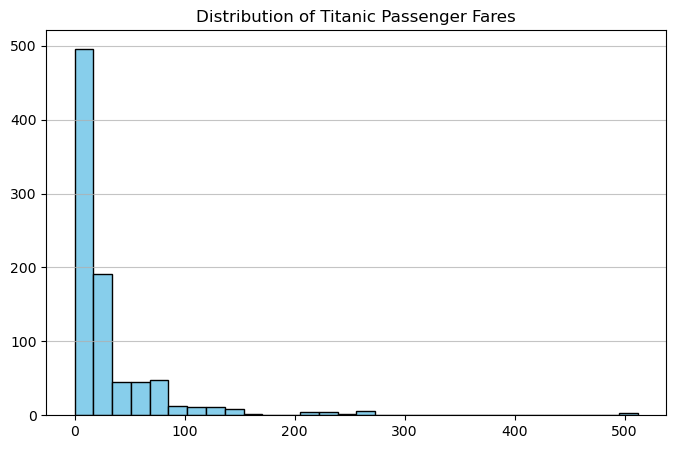

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.hist(df['Fare'], bins = 30, color = 'skyblue', edgecolor = 'black') 
plt.title('Distribution of Titanic Passenger Fares')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

#we have a right skewed data set
#its not normally distributer

#to deal with right skewed data we use a log distribution

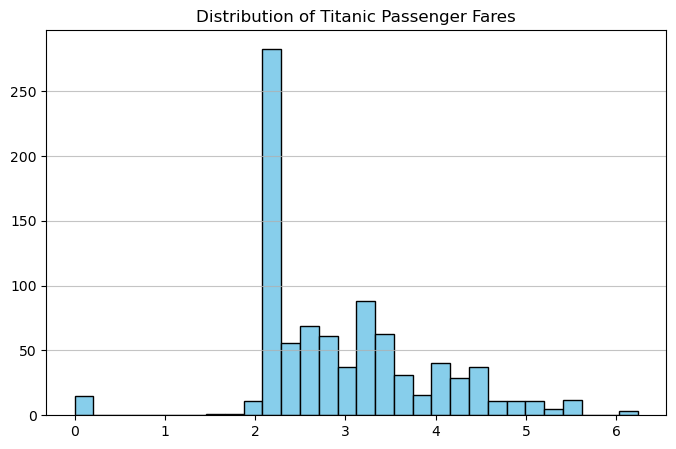

In [107]:
plt.figure(figsize = (8,5))
plt.hist(np.log1p(df['Fare']), bins = 30, color = 'skyblue', edgecolor = 'black') 
plt.title('More Normalized Distribution of Titanic Passenger Fares')
plt.grid(axis = 'y', alpha = 0.75)
plt.show()